In [2]:
# ============================================================
# ASSIGNMENT 3 - CLASSIFICATION
# Star Classification Dataset
# SVM vs Decision Tree
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 70)
print("ASSIGNMENT 3 - CLASSIFICATION")
print("=" * 70)


ASSIGNMENT 3 - CLASSIFICATION


In [6]:
# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

file_path = r"C:\Users\vkvar\Downloads\archive (3)\StarClassificationDataset.csv"

df = pd.read_csv(file_path)

print("\n1. DATASET LOADED")
print("-" * 70)
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])




1. DATASET LOADED
----------------------------------------------------------------------
Dataset shape: (100000, 18)
Number of rows: 100000
Number of columns: 18


C:\Users\vkvar\AppData\Local\Temp\ipykernel_16812\1753560116.py:7: DtypeWarning: Columns (1: alpha, 8: run_ID) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [7]:
# ------------------------------------------------------------
# 3. DISPLAY DATASET INFORMATION
# ------------------------------------------------------------

print("\n2. DATASET COLUMNS")
print("-" * 70)

print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nClass distribution:")
print(df["class"].value_counts())




2. DATASET COLUMNS
----------------------------------------------------------------------
['object_ID', 'alpha', 'delta', 'UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'red_shift', 'plate_ID', 'MJD', 'fiber_ID', 'class']

First 5 rows:
      object_ID        alpha      delta  UV_filter  green_filter  red_filter  \
0  1.240000e+18  135.6891066  32.494632   23.87882      22.27530    20.39501   
1  1.240000e+18  144.8261006  31.274185   24.77759      22.83188    22.58444   
2  1.240000e+18  142.1887896  35.582444   25.26307      22.66389    20.60976   
3  1.240000e+18  338.7410378  -0.402828   22.13682      23.77656    21.61162   
4  1.240000e+18  345.2825932  21.183866   19.43718      17.58028    16.49747   

   near_IR_filter  IR_filter run_ID  rerun_ID  cam_col  field_ID  \
0        19.16573   18.79371   3606       301        2        79   
1        21.16812   21.61427   4518       301        5    

In [8]:
# ------------------------------------------------------------
# 4. CLEAN DATA
# ------------------------------------------------------------

print("\n3. DATA CLEANING")
print("-" * 70)

# Convert important numerical columns to numeric
numeric_columns = [
    "alpha",
    "delta",
    "UV_filter",
    "green_filter",
    "red_filter",
    "near_IR_filter",
    "IR_filter",
    "red_shift"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Remove missing values
before_cleaning = len(df)

df = df.dropna(
    subset=numeric_columns + ["class"]
).copy()

after_cleaning = len(df)

print("Rows before cleaning:", before_cleaning)
print("Rows after cleaning:", after_cleaning)
print("Rows removed:", before_cleaning - after_cleaning)




3. DATA CLEANING
----------------------------------------------------------------------
Rows before cleaning: 100000
Rows after cleaning: 99996
Rows removed: 4


In [9]:
# ------------------------------------------------------------
# 5. SELECT FEATURES AND TARGET
# ------------------------------------------------------------

features = [
    "alpha",
    "delta",
    "UV_filter",
    "green_filter",
    "red_filter",
    "near_IR_filter",
    "IR_filter",
    "red_shift"
]

X = df[features]
y = df["class"]

print("\n4. FEATURES AND TARGET")
print("-" * 70)

print("Features used:")
for feature in features:
    print("-", feature)

print("\nTarget variable: class")




4. FEATURES AND TARGET
----------------------------------------------------------------------
Features used:
- alpha
- delta
- UV_filter
- green_filter
- red_filter
- near_IR_filter
- IR_filter
- red_shift

Target variable: class


In [10]:
# ------------------------------------------------------------
# 6. ENCODE TARGET CLASSES
# ------------------------------------------------------------

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\n5. CLASS ENCODING")
print("-" * 70)

print("Original classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
for number, class_name in enumerate(label_encoder.classes_):
    print(number, "=", class_name)




5. CLASS ENCODING
----------------------------------------------------------------------
Original classes:
['GALAXY' 'QSO' 'STAR']

Encoded classes:
0 = GALAXY
1 = QSO
2 = STAR


In [12]:
# ------------------------------------------------------------
# 7. STANDARDIZE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\n6. FEATURE STANDARDIZATION")
print("-" * 70)
print("Standardization completed successfully.")



6. FEATURE STANDARDIZATION
----------------------------------------------------------------------
Standardization completed successfully.



7. 2D t-SNE VISUALIZATION
Number of samples used for t-SNE: 5000
Running t-SNE... Please wait.
t-SNE completed.


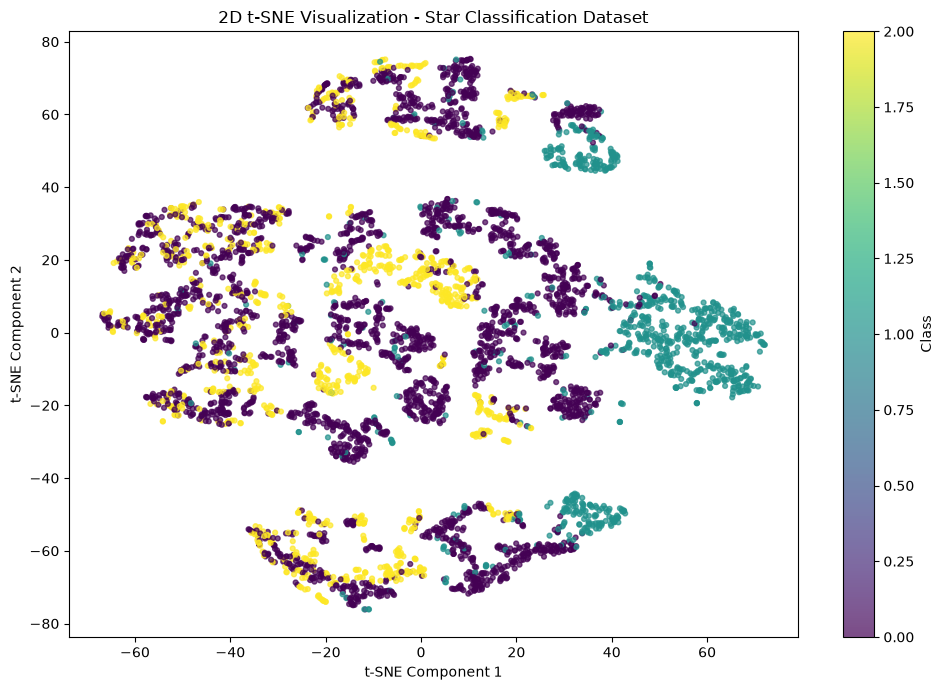

Saved: tsne_plot.png


In [14]:
# ============================================================
# 8. t-SNE VISUALIZATION
# ============================================================

print("\n" + "=" * 70)
print("7. 2D t-SNE VISUALIZATION")
print("=" * 70)

# t-SNE is computationally expensive.
# Therefore, use 5000 samples for visualization.

TSNE_SAMPLES = min(5000, len(X_scaled))

# Use a fixed random sample
rng = np.random.RandomState(42)

tsne_indices = rng.choice(
    len(X_scaled),
    size=TSNE_SAMPLES,
    replace=False
)

X_tsne = X_scaled[tsne_indices]
y_tsne = y_encoded[tsne_indices]

print("Number of samples used for t-SNE:", TSNE_SAMPLES)
print("Running t-SNE... Please wait.")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

X_tsne_result = tsne.fit_transform(X_tsne)

print("t-SNE completed.")

# Plot t-SNE
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne_result[:, 0],
    X_tsne_result[:, 1],
    c=y_tsne,
    cmap="viridis",
    s=12,
    alpha=0.7
)

plt.title(
    "2D t-SNE Visualization - Star Classification Dataset"
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

colorbar = plt.colorbar(scatter)
colorbar.set_label("Class")

plt.tight_layout()

plt.savefig(
    "tsne_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: tsne_plot.png")



In [18]:
# ============================================================
# 9. CREATE BALANCED MODELING DATASET
# ============================================================

print("\n" + "=" * 70)
print("8. PREPARING DATA FOR CLASSIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# STEP 1: Clean column names
# ------------------------------------------------------------
df.columns = (
    df.columns
    .astype(str)
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

print("Available columns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# STEP 2: Define target column
# ------------------------------------------------------------
target_column = "class"

if target_column not in df.columns:
    raise ValueError(
        f"Target column '{target_column}' was not found.\n"
        f"Available columns are:\n{df.columns.tolist()}"
    )

# ------------------------------------------------------------
# STEP 3: Number of samples per class
# ------------------------------------------------------------
MODEL_SAMPLES_PER_CLASS = 6667

# ------------------------------------------------------------
# STEP 4: Create balanced dataset
# ------------------------------------------------------------
sampled_groups = []

for class_name, group in df.groupby(target_column):

    n_samples = min(
        MODEL_SAMPLES_PER_CLASS,
        len(group)
    )

    sampled_group = group.sample(
        n=n_samples,
        random_state=42
    )

    sampled_groups.append(sampled_group)

model_df = pd.concat(
    sampled_groups,
    ignore_index=True
)

# ------------------------------------------------------------
# STEP 5: Separate input and target
# ------------------------------------------------------------
X_model = model_df[features]

y_model = model_df[target_column]

# ------------------------------------------------------------
# STEP 6: Encode target
# ------------------------------------------------------------
y_model_encoded = label_encoder.transform(y_model)

# ------------------------------------------------------------
# STEP 7: Standardize modeling data
# ------------------------------------------------------------
X_model_scaled = scaler.transform(X_model)

# ------------------------------------------------------------
# STEP 8: Display results
# ------------------------------------------------------------
print("\nNumber of observations used for classification:",
      len(model_df))

print("\nClass distribution in modeling dataset:")
print(model_df[target_column].value_counts())

print("\nModeling dataset created successfully!")


8. PREPARING DATA FOR CLASSIFICATION
Available columns:
['object_ID', 'alpha', 'delta', 'UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'red_shift', 'plate_ID', 'MJD', 'fiber_ID', 'class']

Number of observations used for classification: 20001

Class distribution in modeling dataset:
class
GALAXY    6667
QSO       6667
STAR      6667
Name: count, dtype: int64

Modeling dataset created successfully!


In [19]:

# ============================================================
# 10. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_model_scaled,
    y_model_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_model_encoded
)

print("\n9. TRAIN-TEST SPLIT")
print("-" * 70)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))




9. TRAIN-TEST SPLIT
----------------------------------------------------------------------
Training samples: 16000
Testing samples: 4001


In [26]:
# ============================================================
# 11. RESOURCE MONITORING FUNCTION
# ============================================================

process = psutil.Process(os.getpid())


def get_memory_usage_mb():
    return process.memory_info().rss / (1024 * 1024)


def train_and_evaluate(model, model_name):
    
    print("\n" + "-" * 70)
    print(model_name)
    print("-" * 70)

    memory_before = get_memory_usage_mb()

    start_time = time.time()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    end_time = time.time()

    memory_after = get_memory_usage_mb()

    execution_time = end_time - start_time
    memory_used = memory_after - memory_before

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Confusion Matrix
    cm = confusion_matrix(
        y_test,
        y_pred
    )

    # Print metrics
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("Execution Time:", round(execution_time, 3), "seconds")
    print("Memory Change:", round(memory_used, 2), "MB")

    # Plot confusion matrix
    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(
        "Confusion Matrix - " + model_name
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()

    # Create safe filename
    filename = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("=", "")
        .replace(",", "")
    )

    plt.savefig(
        "confusion_matrix_" + filename + ".png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved: confusion_matrix_" +
        filename +
        ".png"
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Execution Time (seconds)": execution_time,
        "Memory Change (MB)": memory_used
    }


In [29]:
# ============================================================
# 12. STORE ALL RESULTS
# ============================================================

results = []




SVM CLASSIFIER

----------------------------------------------------------------------
SVM Linear
----------------------------------------------------------------------
Accuracy : 0.9528
Precision: 0.9527
Recall   : 0.9528
F1 Score : 0.9526
Execution Time: 4.292 seconds
Memory Change: -1.06 MB


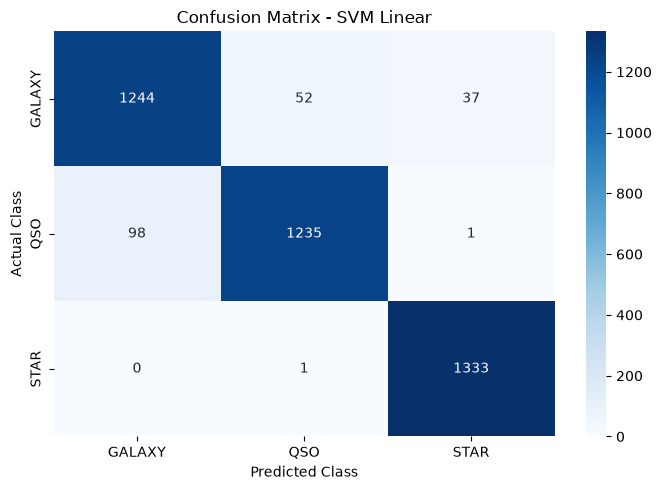

Saved: confusion_matrix_svm_linear.png


In [31]:
# ============================================================
# 13. SVM - LINEAR KERNEL
# ============================================================

print("\n" + "=" * 70)
print("SVM CLASSIFIER")
print("=" * 70)

svm_linear = SVC(
    kernel="linear"
)

result = train_and_evaluate(
    svm_linear,
    "SVM Linear"
)

results.append(result)




----------------------------------------------------------------------
SVM Polynomial
----------------------------------------------------------------------
Accuracy : 0.909
Precision: 0.912
Recall   : 0.909
F1 Score : 0.9089
Execution Time: 7.336 seconds
Memory Change: 1.27 MB


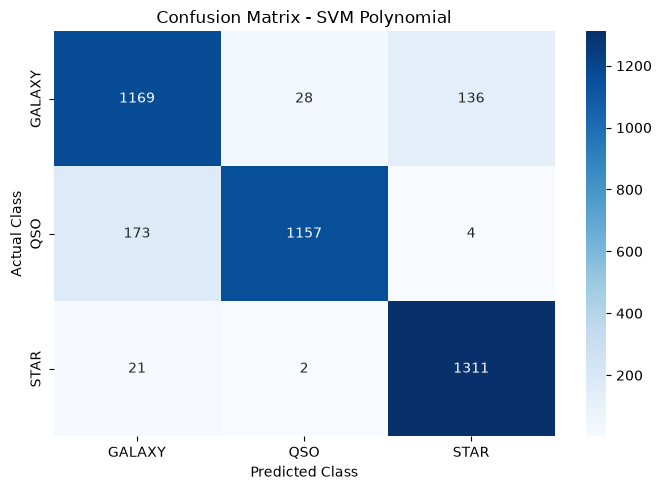

Saved: confusion_matrix_svm_polynomial.png


In [33]:
# ============================================================
# 14. SVM - POLYNOMIAL KERNEL
# ============================================================

svm_poly = SVC(
    kernel="poly",
    degree=3
)

result = train_and_evaluate(
    svm_poly,
    "SVM Polynomial"
)

results.append(result)




----------------------------------------------------------------------
SVM RBF
----------------------------------------------------------------------
Accuracy : 0.9518
Precision: 0.9525
Recall   : 0.9518
F1 Score : 0.9516
Execution Time: 6.891 seconds
Memory Change: 25.11 MB


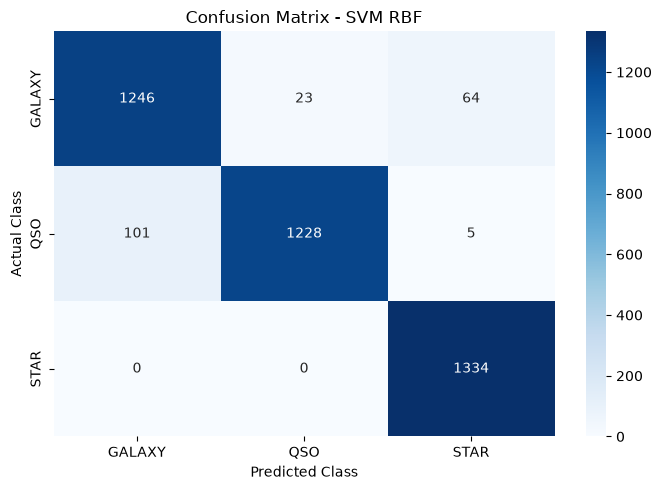

Saved: confusion_matrix_svm_rbf.png


In [35]:
# ============================================================
# 15. SVM - RBF KERNEL
# ============================================================

svm_rbf = SVC(
    kernel="rbf"
)

result = train_and_evaluate(
    svm_rbf,
    "SVM RBF"
)

results.append(result)



DECISION TREE CLASSIFIER

----------------------------------------------------------------------
Decision Tree depth=5 split=2
----------------------------------------------------------------------
Accuracy : 0.9573
Precision: 0.959
Recall   : 0.9573
F1 Score : 0.9572
Execution Time: 0.111 seconds
Memory Change: 0.0 MB


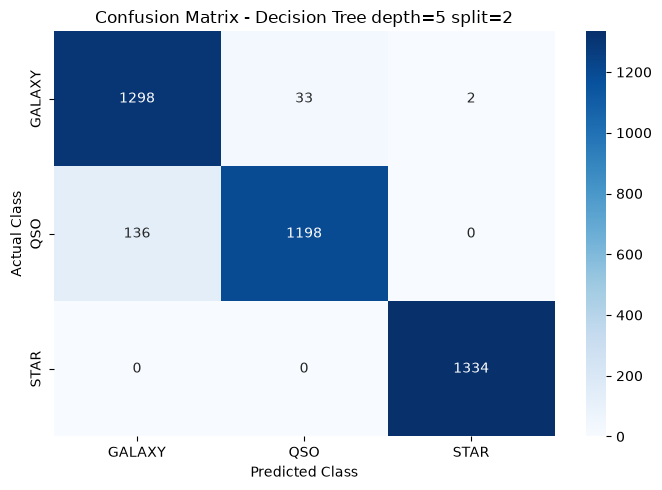

Saved: confusion_matrix_decision_tree_depth5_split2.png

----------------------------------------------------------------------
Decision Tree depth=10 split=2
----------------------------------------------------------------------
Accuracy : 0.9643
Precision: 0.9643
Recall   : 0.9643
F1 Score : 0.9643
Execution Time: 0.148 seconds
Memory Change: 0.0 MB


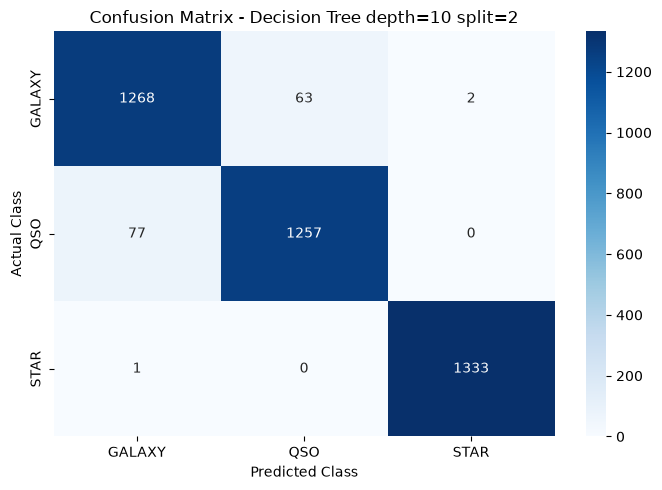

Saved: confusion_matrix_decision_tree_depth10_split2.png

----------------------------------------------------------------------
Decision Tree depth=15 split=2
----------------------------------------------------------------------
Accuracy : 0.9623
Precision: 0.9623
Recall   : 0.9623
F1 Score : 0.9623
Execution Time: 0.211 seconds
Memory Change: 1.45 MB


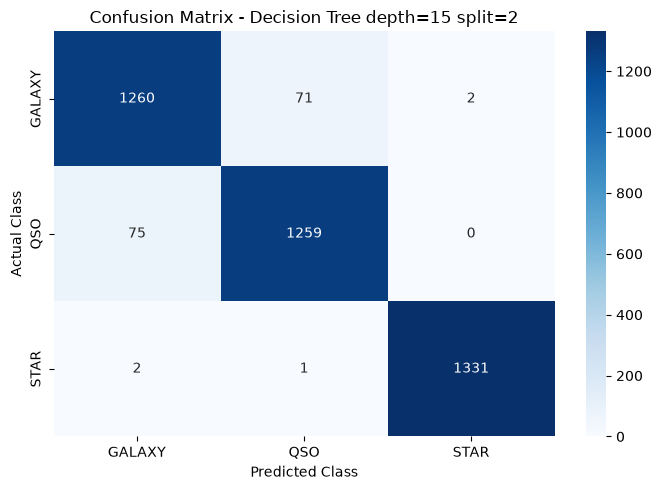

Saved: confusion_matrix_decision_tree_depth15_split2.png

----------------------------------------------------------------------
Decision Tree depth=10 split=10
----------------------------------------------------------------------
Accuracy : 0.9623
Precision: 0.9623
Recall   : 0.9623
F1 Score : 0.9623
Execution Time: 0.147 seconds
Memory Change: 0.0 MB


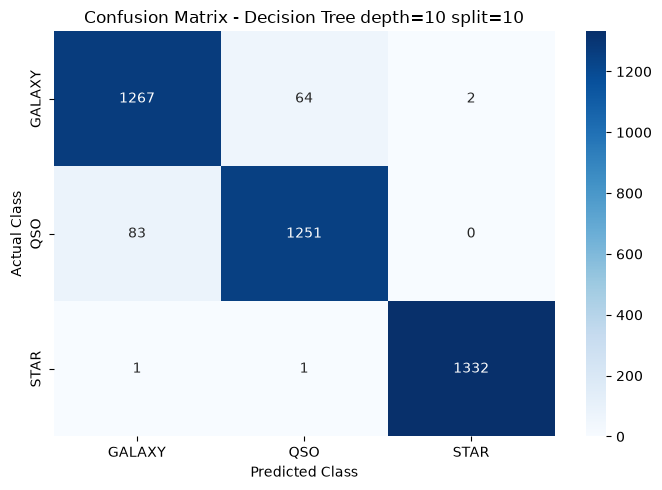

Saved: confusion_matrix_decision_tree_depth10_split10.png

----------------------------------------------------------------------
Decision Tree depth=15 split=10
----------------------------------------------------------------------
Accuracy : 0.9635
Precision: 0.9635
Recall   : 0.9635
F1 Score : 0.9635
Execution Time: 0.173 seconds
Memory Change: 0.04 MB


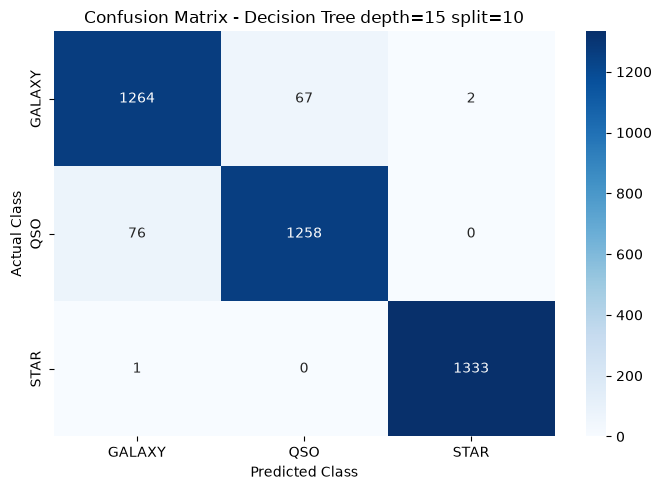

Saved: confusion_matrix_decision_tree_depth15_split10.png


In [37]:
# ============================================================
# 16. DECISION TREE CLASSIFIERS
# ============================================================

print("\n" + "=" * 70)
print("DECISION TREE CLASSIFIER")
print("=" * 70)

tree_settings = [
    (5, 2),
    (10, 2),
    (15, 2),
    (10, 10),
    (15, 10)
]

for max_depth, min_samples_split in tree_settings:

    tree = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )

    model_name = (
        "Decision Tree "
        "depth=" + str(max_depth) +
        " split=" + str(min_samples_split)
    )

    result = train_and_evaluate(
        tree,
        model_name
    )

    results.append(result)


In [39]:

# ============================================================
# 17. FINAL RESULTS TABLE
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

results_df = pd.DataFrame(results)

# Round numerical values
results_df["Accuracy"] = results_df["Accuracy"].round(4)
results_df["Precision"] = results_df["Precision"].round(4)
results_df["Recall"] = results_df["Recall"].round(4)
results_df["F1 Score"] = results_df["F1 Score"].round(4)
results_df["Execution Time (seconds)"] = \
    results_df["Execution Time (seconds)"].round(3)
results_df["Memory Change (MB)"] = \
    results_df["Memory Change (MB)"].round(2)

print(results_df.to_string(index=False))



FINAL MODEL COMPARISON
                          Model  Accuracy  Precision  Recall  F1 Score  Execution Time (seconds)  Memory Change (MB)
                     SVM Linear    0.9528     0.9527  0.9528    0.9526                     4.482               -0.90
                     SVM Linear    0.9528     0.9527  0.9528    0.9526                     4.292               -1.06
                 SVM Polynomial    0.9090     0.9120  0.9090    0.9089                     7.694                3.89
                 SVM Polynomial    0.9090     0.9120  0.9090    0.9089                     7.336                1.27
                        SVM RBF    0.9518     0.9525  0.9518    0.9516                     6.125               -3.38
                        SVM RBF    0.9518     0.9525  0.9518    0.9516                     6.891               25.11
  Decision Tree depth=5 split=2    0.9573     0.9590  0.9573    0.9572                     0.109                0.14
 Decision Tree depth=10 split=2    0.964

In [41]:
# ============================================================
# 18. SAVE RESULTS TO CSV
# ============================================================

results_df.to_csv(
    "classification_results.csv",
    index=False
)

print("\nSaved: classification_results.csv")



Saved: classification_results.csv


In [42]:
# ============================================================
# 19. SAVE CLASS DISTRIBUTION
# ============================================================

class_distribution = df["class"].value_counts()

class_distribution.to_csv(
    "class_distribution.csv"
)

print("Saved: class_distribution.csv")


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ASSIGNMENT 3 COMPLETED")
print("=" * 70)

print("""
Files generated:

1. tsne_plot.png
2. classification_results.csv
3. class_distribution.csv
4. Confusion matrix images for all models

Models tested:

SVM:
- Linear Kernel
- Polynomial Kernel
- RBF Kernel

Decision Tree:
- Different max_depth values
- Different min_samples_split values

Metrics calculated:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Execution Time
- Memory Usage

Your Assignment 3 classification analysis is complete.
""")

print("=" * 70)

Saved: class_distribution.csv

ASSIGNMENT 3 COMPLETED

Files generated:

1. tsne_plot.png
2. classification_results.csv
3. class_distribution.csv
4. Confusion matrix images for all models

Models tested:

SVM:
- Linear Kernel
- Polynomial Kernel
- RBF Kernel

Decision Tree:
- Different max_depth values
- Different min_samples_split values

Metrics calculated:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Execution Time
- Memory Usage

Your Assignment 3 classification analysis is complete.

